# Pipeline Preditivo para Manutenção Industrial

## Projeto Avaliativo - Módulo 1

**Aluno:** Cristiano Saldanha Vargas

**Objetivo**

Desenvolver um pipeline baseado em Machine Learning para prever falhas mecânicas em equipamentos através de classificação algorítmica

# Estrutura do Projeto

1. Importação de bibliotecas
2. Leitura da base de dados
3. **Fase 1** - Análise Exploratória (EDA)
4. **Fase 2** - Data Prep
5. **Fase 3** - Feature Engineering
6. **Fase 4** - Divisão dos Dados
7. **Fase 5** - Escalonamento
8. **Fase 6** - Treinamento dos Modelos
9. **Fase 7** - Avaliação dos Resultados
10. Conclusão





In [1]:
# Importando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

# **Fase 1:** Análise Exploratória de Dados (EDA)

Vamos fazer uma análise da base de dados para conhecer a estrutura, verificar as variáveis e suas características e identificar os problemas que poderão ocorrer e influenciar no treinamento do Modelo de Machine Learning.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving manutencao_preditiva.csv to manutencao_preditiva.csv


In [3]:
df = pd.read_csv("manutencao_preditiva.csv")

In [4]:
df.head()


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [5]:
df.tail()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500.0,40.2,30,0,0,0,0,0,0


In [6]:
df.sample(5, random_state=42)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
6252,6253,L53432,L,NaN,NaN,NaN,NaN,198,0,0,0,0,0,0
4684,4685,M19544,M,NaN,NaN,NaN,NaN,101,1,0,0,0,0,0
1731,1732,M16591,M,NaN,NaN,NaN,NaN,117,0,0,0,0,0,0
4742,4743,L51922,L,NaN,NaN,NaN,NaN,14,0,0,0,0,0,0
4521,4522,L51701,L,NaN,NaN,NaN,NaN,129,0,0,0,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

### Análise Inicial

Carregamos a base de dados referente ao monitoramento dos equipamentos. Há variáveis numéricas e categóricas junto com a variável "falha_maquina" que será usada na modelagem do sistema. Não se verificou problemas de leitura, o que significa que a base de dados poderá ser utilizada para a EDA mais detalhadamente.

#Dimensões da Base de Dados
Vamos identificar o tamanho da base de dados para entender o volume dos registros para treinamento e avaliação dos modelos de Machine Learning

In [8]:
# Conhecendo o número de linhas e colunas
print("Dimensões da base:", df.shape)

print("Número de Linhas:", df.shape[0])

print("Numero de colunas:", df.shape[1])


Dimensões da base: (10000, 14)
Número de Linhas: 10000
Numero de colunas: 14


### Interpretação de Dados
Temos no arquivo da base **10.000** registros em **14 colunas (variáveis)**, o que possibilita o desenvolvimento de modelos de classificação. Podemos dividir os dados em conjuntos de treinamento e teste sem comprometer o aprendizado dos algoritmos.


## 2. Tipos de Dados
Identificar os dados da base para verificar quais são numéricas ou categóricas e valores ausentes que teremos que tratar.

In [9]:
# Identificando os tipos de colunas
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

### Análise dos Tipos de Dados
A base possui **10.000 registros** deivididos em **14 colunas/variáveis**:
*   **8 variáveis do tipo inteiro ('int64')**, que são identificadores, dados de desgaste do equipamento e indicadores de falha;
*   **4 variáveis do tipo decimal ('float64')**, que representam as medições dos sensores da máquina;
*   **2 variáveis do tipo categóricas ('object')**, que representam as medições dos sensores da máquina.

Foi identificado que nas colunas **temperatura_ar_k**, **temperatura_processo_k**, **velocidade_rotacao_rpm** e **torque_nm** há somente *9.500 valores*, indicando que há *500 registros faltantes em cada uma dessas variáveis**. Isso será tratado na fase de preparação de dados (Data Prep).

In [10]:
df.dtypes

,0
udi,int64
id_produto,object
tipo,object
temperatura_ar_k,float64
temperatura_processo_k,float64
velocidade_rotacao_rpm,float64
torque_nm,float64
desgaste_ferramenta_min,int64
falha_maquina,int64
falha_twf,int64


### Interpretação
A base possui variáveis numéricas (12) e categóricas (2).

  * As variáveis numéricas mostram informações medidas pelos sensores, com exceção da coluna (udi), que ordena as linhas da base de dados.
  * Já as colunas categóricas identificam o equipamento monitorado e sua classificação (Tipo).

Identificamos que pelo menos 4 colunas apresentam dados ausentes, que serão tratados na fase de Data Prep (preparação de dados), para garantir a qualidade do treinamento dos modelos de Machine Learning.


## 3. Estatísticas Descritivas
Vamos utilizar as informações de média, desvio padrão, mínimo, máximo e quartis para identificar assimetrias e/ou valores extremos que possam prejudicar os modelos de Machine Learning.


In [11]:
# Estatísticas descritivas
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Análise Estatística Descritiva
Avaliação do comportamento das variáveis numéricas para verificação de dados que possam impactar no treinamento dos modelos de Machine Learning.

*   As temperaturas de ar e de processo mostram uma peaquena variação em suas médias, o que mostra estabilidade na operação dos equipamentos;
*   Há uma dispersão mais acentuada entre a velocidade de rotação e o torque, o que pode identificar diferentes tipos de operação entre os equipamentos;
*   Na variável *falha_maquina*, a média informa uma valor de *0,033900** rerepsentando 3,39% de máquinas que apresentaram falhas em comparação com funcionamento normal, sugerindo um desbalanceamento da base. Esta informação será ajustada no decorrer do processo, utilizando técnicas de balanceamento de dados.




## 4. Distribuição das Variáveis Contínuas

Avaliação das distribuições das variáveis contínuas que são monitoradas pelos sensores nos equipamentos.
Os histogramas gerados auxiliam na visualização da distribuição dos valores, buscando indicadores que podem indicar assimetrias, concentrações, discrepâncias (Outliers).
Esta visualização vai justificar a escolha dos dados para treinamento dos modelos.


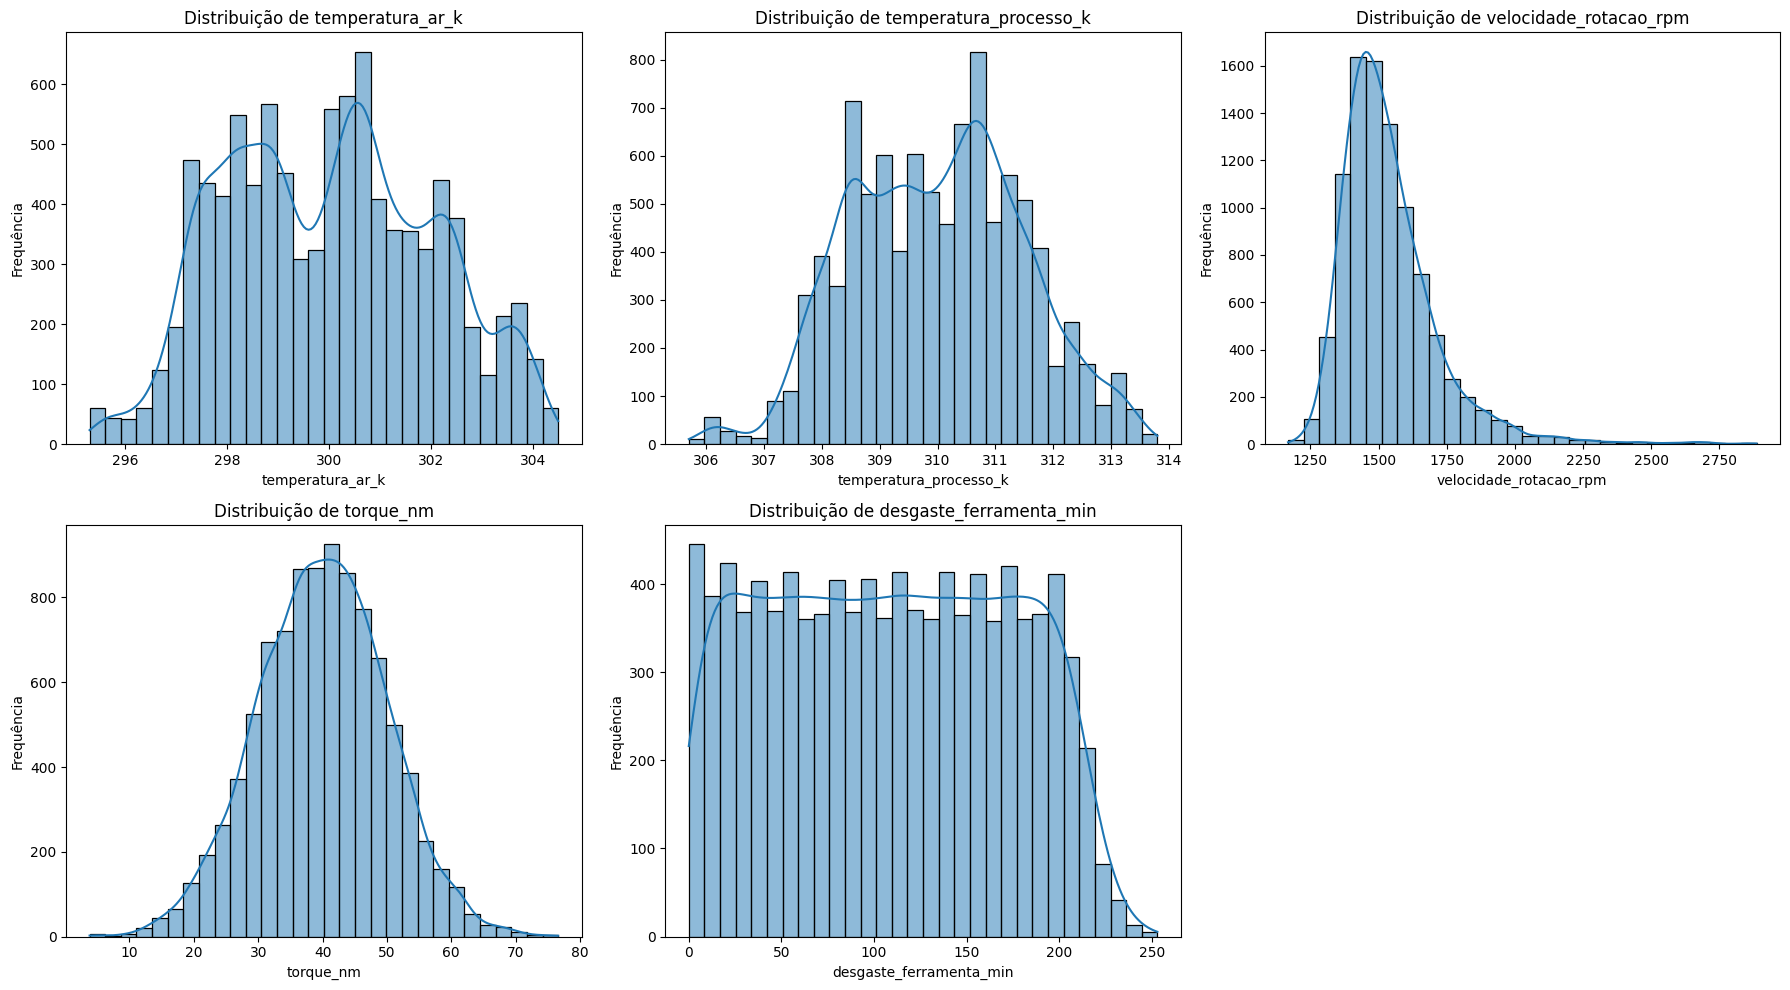

In [12]:
# Lista das variáveis

variaveis_continuas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(18,10))

for i, coluna in enumerate(variaveis_continuas):
    plt.subplot(2, 3,i+1)
    sns.histplot(
        data=df,
        x=coluna,
        kde=True,
        bins=30)
    plt.title(f'Distribuição de {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

### Análise dos Histogramas
As distribuições mostram comportamentos diferenciados entre as variáveis monitoradas. Seguem as considerações:
*   Variáveis **temperatura_ar_k** e **temperatura_processo_k** têm intervalos relativamente estreitos, o que indica uma certa estabilidade nas condições durante a coleta;
*   Variável **torque_nm** aparenta uma distribuição praticamente simética, em uma distribuição relativamente normal, indicando certa estabilidade operacional e não relacionado a fatores externos;
*   Variável **velocidade_rotacao_rpm** possui uma assimetria positiva, com grande parte dos resultados na faixa entre 1350 e 1650 RPM, apresentando uma cauda longa à direita, mostrando equipamentos que operam em rotações mais altas, o que será investigado no decorrer do processo;
*   variável **desgaste_ferramenta_min** também possui distribuição praticamente uniforme, o que indica que há equipamentos em vários estágios de utilização, o que é importante em modelos de manutenção preditiva.
Utilizaremos estes dados para apoio na etapa de tratamento de dados.

## 5. Distribuição da Variável Alvo
Avaliação da variável "falha_maquina" para identificar possíveis desbalanceamentos entre as classes, especialmente em dados que possuem uma parte pequena de acionamentos.
Com esse apareceimento, é possível desenvolver técnicas de balanceamento de dados para a preparação do treinamento dos modelos.

In [13]:
#Quantidade de registros por classe
df['falha_maquina'].value_counts()


,count
falha_maquina,
0,9661
1,339


In [14]:
df['falha_maquina'].value_counts(normalize=True)*100

,proportion
falha_maquina,
0,96.61
1,3.39


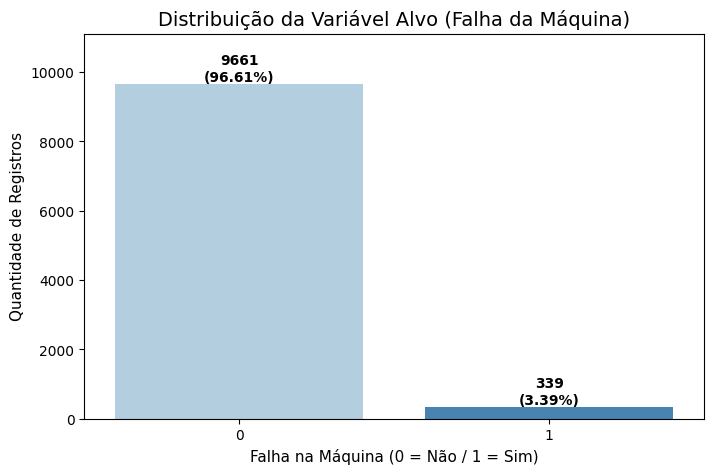

In [15]:
# Contagem das classes

contagem = df['falha_maquina'].value_counts().sort_index()
percentual = (contagem / len(df) * 100).round(2)


# Criação do gráfico de barras

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='falha_maquina',
    hue='falha_maquina',
    palette='Blues',
    legend=False
)

ax.set_ylim(0, contagem.max() * 1.15)

plt.title(
    'Distribuição da Variável Alvo (Falha da Máquina)',
    fontsize=14,
    pad=20
)

plt.title('Distribuição da Variável Alvo (Falha da Máquina)', fontsize=14)
plt.xlabel('Falha na Máquina (0 = Não / 1 = Sim)', fontsize=11)
plt.ylabel('Quantidade de Registros', fontsize=11)

for i, p in enumerate(ax.patches):
    ax.annotate(
        f'{contagem.iloc[i]}\n({percentual.iloc[i]}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

### Interpretação dos Resultados
A distribuição da variável **falha_maquina** aponta para um forte desbalanceamento entre as classes, pois **96,61%** dos registros mostram um funcionamento "normal" dos equipamentos (Classe 0) e apenas **3,39%** aponta falhas (classe 1).
Essa baixa frequência de falhas é esperado em ambientes operacionais, onde quanto menor o índice de falha, melhor.
No que diz respeito ao treinamento de modelos de Machine Learning, esse desbalanceamento pode reduzir a capacidade de identificação de falhas.
Nessa caso, utilizaremos técnicas de balanceamento de dados (**SMOTE**) no conjunto de treinamento para reduzir o viés durante no aprendizado e evitar o vazamento de dados (Data Leakage).

## 6. Correlação entre as Variáveis
Vamos analisar o relacionamento entre as variáveis, para verificar seu comportamento em conjunto.
Utilizando a **Correlação de Pearson**, é possível encontrar a intensidade de relação linear entre as variáveis numéricas, utilizando um coeficiente de relação entre **-1 e + 1**.
*   **-1:** Correlação negativa perfeita - Quando uma aumenta, a outra diminui;
*   **0:** Não há correlação entre as variáveis - a variação de uma não explica ou não altera a outra;
*   **+1:** Correlação positiva perfeita - Quando uma aumenta, a outra também aumenta.

Em termos de avaliação, consideramos as seguintes intensidades:
*  | ±0,00 a ±0,19 | Correlação muito fraca |
*  | ±0,20 a ±0,39 | Correlação fraca |
*  | ±0,40 a ±0,59 | Correlação moderada |
*  | ±0,60 a ±0,79 | Correlação forte |
*  | ±0,80 a ±1,00 | Correlação muito forte |

Estes dados nos ajudam a perceber comportamentos semelhantes, redundâncias e relações relevantes que auxiliarão na construção dos modelos preditivos.

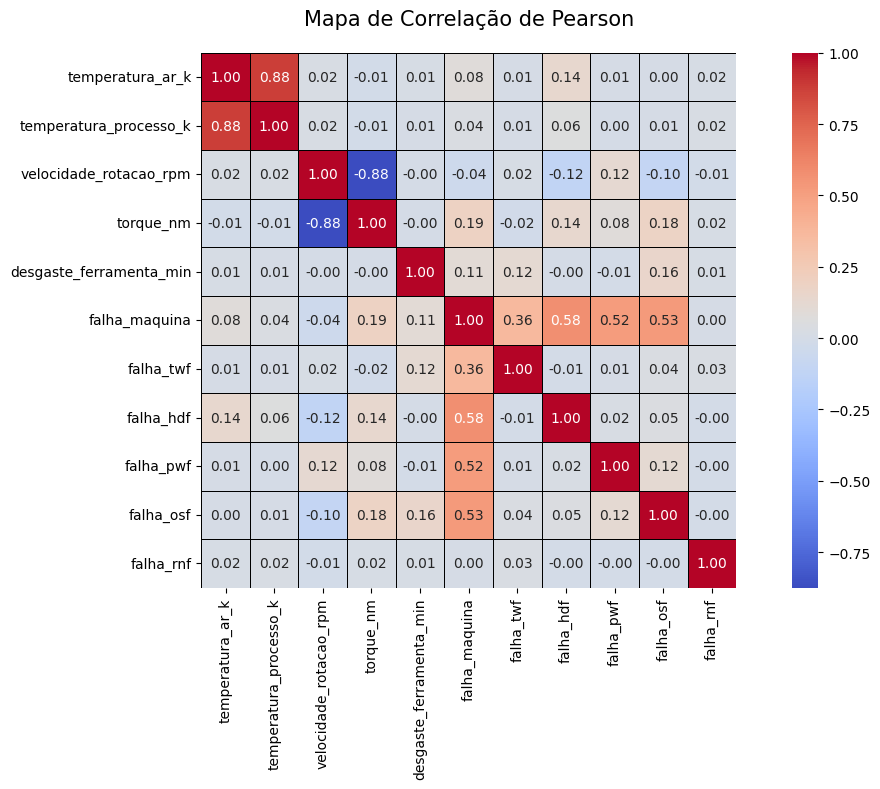

In [16]:
# Seleção das variáveis para a correlação

colunas_corelacao = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'falha_maquina',
    'falha_twf',
    'falha_hdf',
    'falha_pwf',
    'falha_osf',
    'falha_rnf'
]

# Cálculo da Matriz de correlação:
matriz_correlacao = df[colunas_corelacao].corr()

# Visualização da Matriz de correlação:
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True,
    linecolor='black'
)
plt.title('Mapa de Correlação de Pearson',
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.show()

###Interpretação dos Resultados
Foram identificadas relações importantes entre as variáveis monitoradas pelos sensores:

*   **Forte Correlação Positiva (0.88)** entre **temperatura_do_ar_k e temperatura_processo_k**, mostrando que ambas tendem a variar conjuntamente quando os equipamentos estão em operação.
*   **Forte Correlação Negativa (-0.88)** entre **velocidade_rotacao_rpm e torque_nm**, evidenciando relação inversa entre essas grandezas, um comportamento esperado em diferentes regimes de operção de equipamentos industriais;
*   Identificou-se uma forma relação entre  a variável-alvo 'falha_maquina' com as variáveis **falha_hdf (0,58)**, **falha_osf (0,53)** e **falha_pwf (0,52)**, e de uma maneira um pouco menos evidente, com a variável **falha_twf (0,36)**.  Conforme descrito nas anotações da engenharia, essas variáveis representam os motivos técnicos para as falhas já ocorridas e servem apenas para consulta histórica. Essas falhas não serão utilizadas como variáveis preditoras durante o treinamento do modelo, evitando o vazamento de dados ("Data Leakage").

Os resultados mostram que as variáveis específicas de falha estão relacionadas às ocorrências de falha geral da máquina, pois registram o diagnóstico técnico informado após a falha.

Embora algumas variáveis possuam correlações elevadas entre si,elas possuem características físicas diferentes no processo e não foram consideradas redundantes. Por essa razão, elas serão consideradas nas próximas etapas do pipeline.

## Diagnósticos e Considerações da Análise Expolratória
A partir da análise exploratória de dados, identificamos 10.000 registros distribuídos em 14 variáveis, juntamente com valores ausentes em quatro variáveis contínuas, os quais serão tratados na preparação de dados.

Foram identificados comportamentos distintos entre os sensores, destacando a  a assimetria na velocidade de rotação e a maior estabilidade nas variáveis temperatura_ar_k, temperatura_processo_k e torque_nm. O mapa de correlação evidenciou relações importantes entre algumas variáveis, principalmente entre as temperaturas e entre velocidade de rotação e torque, além de confirmar que as variáveis de falhas específicas representam informações de diagnóstico e, portanto, não serão utilizadas como variáveis preditoras, evitando a ocorrência de Data Leakage, conforme orientação do Departamento de Engenharia.

Também foi identificado um forte desbalanceamento da variável-alvo, característica comum em problemas de manutenção preditiva, indicando a necessidade de aplicação de técnicas de balanceamento antes do treinamento dos modelos.

Com a análise exploratória concluída, a base encontra-se devidamente compreendida e pronta para as próximas etapas do pipeline, que envolverão a limpeza e preparação dos dados, a engenharia de atributos e o treinamento dos modelos de Machine Learning.

# Fase 2 - Limpeza e Tratamento dos Dados (Data Preparation)
Após entender o comportamento dos dados, é necessário garantir a qualidade das informações que serão utilizadas no treinamento dos modelos de machine Learning.

Esta etapa fará a identificação e remoção de registros duplicados, tratar valores ausentes e avaliação de valores discrepantes (outliers), garantindo a confiabilidade das etapas seguintes do processo preditivo.

##1. Identificação de Registros Duplicados
Esta identificação é importante para evitar a introdução de vieses quando do treinamento dos modelos de Machine Learning (ML), o que pode aumentar artificialmente a frequência de determinados padrões. Os valores repetidos serão removidos.

In [17]:
#### Verificar Duplicidades ####
# Número de registros antes da remoção
registros_antes = len(df)

# Identifica registros duplicados
duplicados = df.duplicated().sum()

# Remove registros duplicados
df = df.drop_duplicates()

# Número de registros após a remoção
registros_depois = len(df)

# Exibe o resultado da operação
print("=" * 55)
print("      VERIFICAÇÃO DE REGISTROS DUPLICADOS")
print("=" * 55)
print(f"Registros antes da remoção : {registros_antes}")
print(f"Registros duplicados       : {duplicados}")
print(f"Registros após a remoção   : {registros_depois}")
print(f"Total de registros removidos: {registros_antes - registros_depois}")
print("=" * 55)

      VERIFICAÇÃO DE REGISTROS DUPLICADOS
Registros antes da remoção : 10000
Registros duplicados       : 0
Registros após a remoção   : 10000
Total de registros removidos: 0


### Interpretação dos resultados

Não foram encontradas duplicidades nos dados apresentados, o que evidencia que foi feito um registro único para cada monitoramento no equipamento.
Nesse cenário, **não foi necessária a remoção de registros**, o que mantém a quantidade inicial de observações para as próximas etapas do pipeline.
Com a ausência de duplicidades, o risco de vieses estatísticos diminui, garantindo que cada registro demonstre uma única observação durante o treinamento dos modelos de Machine Learning, o que contribui para a qualidade da base de dados.

##2. Identificação dos Valores Ausentes
Os valores ausentes podem comprometer o treinamento em algritmos de ML, pois alguns modelos não aceitam registros contendo campos nulos.
Esta etapa trata da identificação da quantidade e percentual de valores ausentes em cada variável, o que possibilita a ação mais adequada para mitigar estas ausências.

In [18]:
# Verificação de quantidade e percentual de valores ausentes

valores_ausentes = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual de Valores Ausentes (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
})

valores_ausentes

,Valores Ausentes,Percentual de Valores Ausentes (%)
udi,0,0.0
id_produto,0,0.0
tipo,0,0.0
temperatura_ar_k,500,5.0
temperatura_processo_k,500,5.0
velocidade_rotacao_rpm,500,5.0
torque_nm,500,5.0
desgaste_ferramenta_min,0,0.0
falha_maquina,0,0.0
falha_twf,0,0.0


### Interpretação dos Resultados
Na avaliação da base de dados, percebe-se que quaro variáveis apresentam dados faltantes, com 500 valores cada, o que corresponde a 5%: **temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm**.
As outras variáveis não apresentam vaores nulos.
Como a quantidade de valores é baixa entende-se que a melhor alternativa é a imputação de dados ao invés de sua remoção, o que evita a perda de informações no treinamento dos modelos de ML.


##3. Tratamento dos Valores Ausentes
Avaliando a distribuição dos gráficos na estapa de EDA utilizaremos as seguintes técnicas de imputação de dados:

*   Para as variáveis **temperatura_ar_k, temperatura_processo_k e torque_nm**, que apresentaram uma distribuição **aproximadamente simétrica**, utilizaremos a **média** como medida de tendência central
*   Já para a variável **velocidade_rotacao_rpm**, que apresentou uma **assimetria positiva**, utilizaremos a **mediana**, que é menos sensível á influência de valores extremos.



In [19]:
# Imputação de Valores Ausentes

#Média
df['temperatura_ar_k'] = df['temperatura_ar_k'].fillna(df['temperatura_ar_k'].mean())

df['temperatura_processo_k'] = df['temperatura_processo_k'].fillna(df['temperatura_processo_k'].mean())

df['torque_nm'] = df['torque_nm'].fillna(df['torque_nm'].mean())

# Mediana
df['velocidade_rotacao_rpm'] = df['velocidade_rotacao_rpm'].fillna(df['velocidade_rotacao_rpm'].median())

print("Valores ausentes tratados com sucesso!")

Valores ausentes tratados com sucesso!


In [20]:
# Verificando a Imputação de Dados Ausentes

df.isnull().sum()

,0
udi,0
id_produto,0
tipo,0
temperatura_ar_k,0
temperatura_processo_k,0
velocidade_rotacao_rpm,0
torque_nm,0
desgaste_ferramenta_min,0
falha_maquina,0
falha_twf,0


### Interpretação dos Resultados
Os valores ausentes foram tratados conforme as distribuiçõs de cada variável.

As variáveis **temperatura_ar_k**, **temperatura_processo_k** e **torque_nm**, foi utilizada a imputação pela média devido ao comportamento aproximadamente simétrico observado durante a análise exploratória.

Para a variável **velocidade_rotacao_rpm**, optou-se pela imputação utilizando a mediana, uma vez que sua distribuição apresentou assimetria positiva, tornando essa medida mais robusta à influência de valores extremos.

Após este processo, nenhuma variável apresentou valores nulos/ ausentes, qualificando a base para as próximas etapas do pipeline de ML.

##4. Identificação de Outliers
Com a base de dados ajustada sem valores ausentes, é necessário avaliar os valores extremos nas variáveis.
A utilização de Boxplots auxiliam na identificação desses valores, de maneira a interpretar se são erros de coleta ou exceções passíveis de ocorrer dentro dos processos industriais.
A intenção é identificar se existe esse tipo de situação e interpretar esses dados antes do treinamento do modelo de ML.


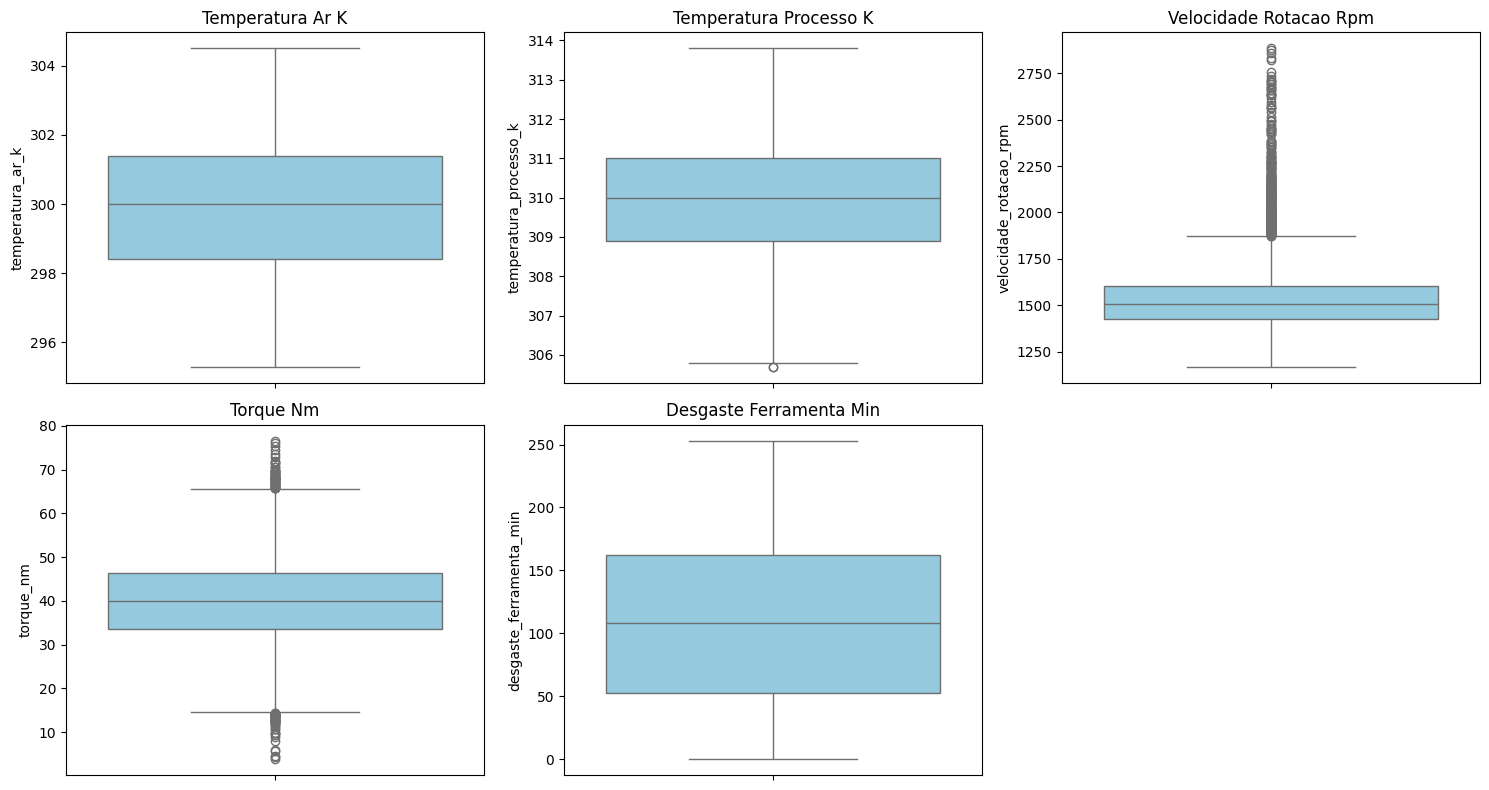

In [21]:
# Variáveis numéricas contínuas

variaveis_continuas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

# Configuração da figura
plt.figure(figsize=(15,8))

# Criação dos boxplots
for i, coluna in enumerate(variaveis_continuas, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[coluna], color='skyblue')
    plt.title(coluna.replace('_',' ').title())

plt.tight_layout()

plt.show()

### Interpretação dos Resultados
Avaliando os boxplots, foram encontrados outliers especialmente nas variáveis **velocidade_rotacao_rpm e torque_nm**. Nas outras variáveis, relacionadas a temperatura, não foram encontrados ocorrencias recorrentes de valores extremos, apresentando distribuições mais homogêneas.
A presença de outliers nas variáveis de velocidade e torque é consideravelmente elevada, justificando que estes dados não são isolados, mas diferentes condições de operação dos equipamentos monitorados.
Neste sendido, entendendo que o projeto se refere a **predição de condições de falha na manutenção preventiva desses equipamentos** estes valores **não serão removidos**. Entende-se que podem ser situações reais de operação ou fatores de desgaste desses equipamentos, sendo relevantes para os algoritmos de ML apender a identificar padrões relacionados a ocorrência de falhas.
Os outliers serão mantidos na base para preservar características originais dos processos industriais, evitando a perde de informações na etapa de modelagem.   

# Fase 3 - Feature Engineering
Consiste na criação de novas variáveis com informações já disponíveis na base de dados, fornecendo aos algoritmos uma melhor representação do comportamento do processo, aumentando o potencial preditivo dos modelos de ML.
Será criada uma variável **potencia**, através do produto entre a velocidade de rotação do eixo e o torque do equipamento.

##Criação de Variável Potência
Conforme os documentos fornecidos pela engenharia, o esforço mecânico nos equipamentos é representado pela combinação entre **velocidade de rotação(RPM) e torque(Nm)**.
Entende-se que na física de materiais a fórmula de potência mecânica real é diferente, mas para fins de avaliação, consideraremos a fórmula **potencia = velocidade_rotacao_rpm x torque_nm**
As informações adicionais dessa nova variável pode mostrar dados do regime de operação desses equipamentos.

In [22]:
# Criando Nova Variavel Potência

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

print("Nova variável criada com sucesso")

Nova variável criada com sucesso


In [23]:
df[['velocidade_rotacao_rpm',
    'torque_nm',
    'potencia']].head()

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


In [24]:
df['potencia'].describe()

,potencia
count,10000.000000
mean,59961.210585
std,9951.106738
min,10966.800000
25%,53497.050000
50%,60121.149305
75%,66412.975000
max,99980.400000


### Interpretação dos Resultados
Variável **potencia** criada com sucesso pela multiplicação da velocidade de rotação e o torque.
Esta nova variável vai possibilitar a identificação de padrões de operação que não seriam evidenciados na avaliação das variáveis torque e velocidade de rotação isoladamente.
A criação de novos atributos aumenta a capacidade dos modelos de Machine Learning a identificar relações complexas entre as variáveis da base de dados.
A nova variável apresentou valores coerentes entre velocidade de rotação e torque, não gerando valores nulos nem inconsistências depois de sua criação, passando a integrar o conjunto de atributos nas próximas etapas do pipeline.


# Fase 4 - Divisão e Balanceamento dos Dados
Com a preparação e engenharia de atributos, iniciamos a construção da base para os algoritmos.
Definiremos as variáveis preditoras (X) e a variável-alvo (y) para depois dividir os dados em conjuntos de treinamento e teste com a amostra estratificada, mantendo a proporção entre classes e variável-alvo.
Depois, será realizado o balanceamento somente na base de treinamento, evitando "Data leakage", que ocorre quando as informações do conjunto de teste influenciam no treinamento dos modelos.


## Separação das Variáveis Preditoras e da Variável-alvo
A variável **falha_maquina** representa o objetivo da predição e será usada como variável0alvo (y).
As outras variáveis serão utilizadas como possíveis atributos preditores, exceto as variáveis de identificação e as informadas pela engenharia que identificam as falhas específicas (**falha_twf**, **falha_hdf**, **falha_pwf**, **falha_osf** e **falha_rnf**). essas variáveis serão removidas do conjunto de atributos para evitar o **Data Leakage**, assegurando que o modelo aprenda apenas com as informações antes  ocorrência da falha.  


## Transformando Variáveis Categóricas
A variável **tipo** é categorica e represena categorias diferentes de máquinas.
Os algoritmos de ML neste projeto trabalham apenas com valores numéricos, por isso essa variável será convertida pela técnica de **One-Hot Encoding**, oreservando todas as categorias mas sem incuir uma relação ordinal entre elas.
Como a categoria possui três classes distintas (**H, L e M**) e o One-Hot Encoding transforma em variáveis binárias, foi utilizado o parâmetro **'drop_first=True'**, que remode uma das categorias, evitando a redundãncia entre as variáveis criadas (Dummy Variable Trap). Assim, foram geradas apenas as colunas **'tipo_L'** e **'tipo_M'**, e a categoria **H** fica representada implicitamente quando ambas as variáveis assumirem o valor zero.
Isso reduz a dimensionalidade do conjuto de dados sem perder informações assim como prepara a variável categórica para os algoritmos KNN e Árvore de Decisão.

In [25]:
# Transformação da variável categórica "tipo"

df = pd.get_dummies(
    df,
    columns=['tipo'],
    drop_first=True,
    dtype=int
)

print("Transformação realizada com sucesso!")

Transformação realizada com sucesso!


In [26]:
print("Categorias após a transformação:")
print(df[['tipo_L', 'tipo_M']].head())

print("\nColunas do DataFrame:")
print(df.columns.tolist())

Categorias após a transformação:
   tipo_L  tipo_M
0       0       1
1       1       0
2       1       0
3       1       0
4       1       0

Colunas do DataFrame:
['udi', 'id_produto', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf', 'potencia', 'tipo_L', 'tipo_M']


### Interpretação dos Resultados
Convertemos com sucesso a variável **tipo** em variáveis binárias **tipo_L** e **tipo_M**, fazendo com que todos os atributos da base sejam numéricos. A categoria **H** passa a ser representada implicitamene, mantendo as informações originais ao mesmo tempo que permite sua utilização pelos algoritmos de ML.

## Divisão da Base em Treino e Teste
Depois de definir as variaveis preditoras (X) e da variável-alvo (y), os dados serão divididos em conjuntos de treinamento e teste.
O projeto solicita que a proporção fique com **80% de dados para treinamento** e **20% dos dados para teste**.
Também é utilizado o parâmetro **stratifyy**, assegurando que a proporção entre máquinas com falha e sem falha seja preservada em ambos os conjuntos. Cmo há um desbalanceamento identificado na variavel-alvo durante a analise Exploratória de Dados (EDA), recomenda-se a utilização dessa estratégia.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# Definindo as variáveis preditoras (X) e a variável alvo (y)
# Removemos os IDs e as colunas de falhas específicas para evitar "data leakage" (vazamento de dados)
colunas_para_remover = ['falha_maquina', 'udi', 'id_produto', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
X = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

y = df['falha_maquina']

In [29]:
#Divisões de base de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
print("Conjunto de Treinamento")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nConjunto de Teste")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Conjunto de Treinamento
X_train: (8000, 8)
y_train: (8000,)

Conjunto de Teste
X_test: (2000, 8)
y_test: (2000,)


In [31]:
print("Distribuição da variável alvo")

print("\nBase original")
print(y.value_counts(normalize=True))

print("\nTreinamento")
print(y_train.value_counts(normalize=True))

print("\nTeste")
print(y_test.value_counts(normalize=True))

Distribuição da variável alvo

Base original
falha_maquina
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Treinamento
falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Teste
falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64


### Interpretação dos Resultados
Realizamos com sucesso a divisão da base de dados em 80% dos registros para treinamento e os 20% para teste, assim como foi utilizado o parâmetro **stratify=y** para reservar as características de proporcionalidade entre as classes da variável **falha_maquina** nos dois conjuntos e dados. Isso evita o desbalanceamento das bases de dados, para que uma avaliação mais confiável seja encontrada nos modelos de Machine Learning.

## Balanceamento da Base de Treinamento
Na EDA encontramos um desbalanceamento da variável **falha_maquina**, com grande presença da classe **Sem falha**.
Quando modelos de ML utilizam bases de treinamento desbalanceadas, o viés tende a priorizar a classe com maior número de ocorrências, reduzindo sua capacidade de identificação de casos reais de falha.
Vamos utilizar o **SMOTE (Synthetic Minority Over-Sampling Technique)** para criar amostras sintéticas da classe minoritária junto aos exemplos que existem no banco de dados, sendo aplicado somente no conjunto de treinamento. Foi utilizada a função **ramdom_state=42** para garantir a reprodutibilidade do experimento, assim a geração das amostras sintéticas é feita de uma mesma maneira, permitindo a outros usuários obter os mesmos resultados ao executar o notebook.
O Conjunto de teste será mantido em sua distribuição original para evitar o **Data Leakage**.


In [32]:
# Importando o SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [33]:
#Verificando balanceamento antes do SMOTE
print("Distribuição da variável alvo antes do SMOTE:\n")

print(y_train.value_counts())

print("\nPercentual:")

print((y_train.value_counts(normalize=True)*100).round(2))

Distribuição da variável alvo antes do SMOTE:

falha_maquina
0    7729
1     271
Name: count, dtype: int64

Percentual:
falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


In [34]:
#Aplicando SMOTE somente na base de treinamento (alterando apenas a base de treinameto X_train e y_train; X_test e y_test permanecem inalterados)
smote = SMOTE(
    random_state=42
)

X_train_balanceado, y_train_balanceado = smote.fit_resample(
    X_train,
    y_train
)

In [35]:
#Conferindo o balanceamento
print("Distribuição após o SMOTE:\n")

print(y_train_balanceado.value_counts())

print("\nPercentual:")

print((y_train_balanceado.value_counts(normalize=True)*100).round(2))

Distribuição após o SMOTE:

falha_maquina
0    7729
1    7729
Name: count, dtype: int64

Percentual:
falha_maquina
0    50.0
1    50.0
Name: proportion, dtype: float64


In [36]:
#Comparação antes e depois do SMOTE na base de treinamento
comparacao = pd.DataFrame({
    "Antes do SMOTE": y_train.value_counts(),
    "Depois do SMOTE": y_train_balanceado.value_counts()
})

comparacao

,Antes do SMOTE,Depois do SMOTE
falha_maquina,,
0,7729,7729
1,271,7729


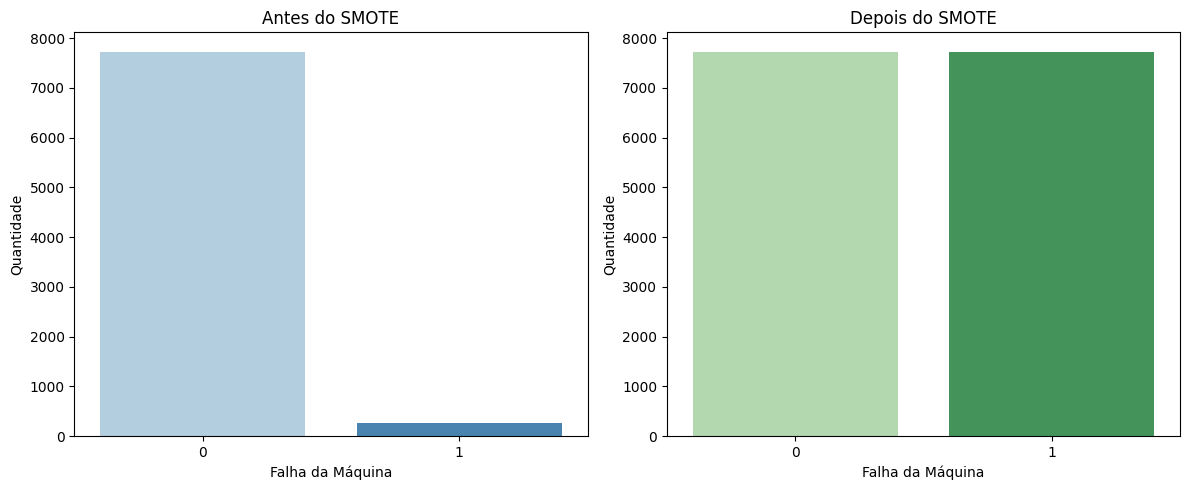

In [37]:
# Gráfico Comparativo antes x depois do SMOTE
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.countplot(
    x=y_train,
    ax=axes[0],
    hue=y_train,
    palette="Blues",
    legend=False
)

axes[0].set_title("Antes do SMOTE")
axes[0].set_xlabel("Falha da Máquina")
axes[0].set_ylabel("Quantidade")

sns.countplot(
    x=y_train_balanceado,
    ax=axes[1],
    hue=y_train_balanceado,
    palette="Greens",
    legend=False
)

axes[1].set_title("Depois do SMOTE")
axes[1].set_xlabel("Falha da Máquina")
axes[1].set_ylabel("Quantidade")

plt.tight_layout()

plt.show()

### Interpretação dos Resultados
O conjunto de dados  original da variável **falha_maquina** apresentava um forte desbalanceamento, evidenciando uma quase totalidade de dados referentes ao funcionamento normal das máquinas.
Com o uso do recurso SMOTE, foi possível sintetizar a base de treinamento de modo a equilibrar as classes da variável, possibilitando um treinamento mais balanceado do modelo de ML.
A base de testes não foi alterada, evitando assim vazamento de dados, o que vai permitir a medição de desempenho semelhante a situações em ambiente real.

# Fase 5 - Escalonamento das Variáveis
Será realiado o escalonamento das variáveis utilizando a ferramenta **StandardScaler**.
Este escalonamento será utilizado **somente nas variáveis contínuas dos dados que serão utilizados no modelo de KNN**, por utilizar medidas de distância para calcular os vizinhos mais próximos, o que mostra uma sensibilidade às diferenças de escala entre os atributos. As variáveis binárias **tipo_L e tipo_M** que foram criadas no processo de One-Hot-Encoding permanecem inalteradas, visto que não possuem medidas contínuas (somente binárias 0 e 1).
Na Árvore de Decisão, treinaremos utilizando os dados originais porque o modelo utiliza de divisões por limites das variáveis, não dependendo da distância entre os registros.

In [38]:
## Importando o StandardScaler
from sklearn.preprocessing import StandardScaler

## Aplicação do StandardScaler
As variáveis numéricas possuem escalas diferentes:
*   Temperatura varia entre 295 e 314 K;
*   Velocidade de rotação varia entre 1.100 e 2.900 RPM
*   Potência possui valores muito mais altos do que as demais.
O escalonamento permite uma padronização dos pesos de cada variável, uma vez que as variáveis que apresentam valores maiores de maior magnitude possuiriam uma maior influência no cálculo das distâncias dentro do altoritmo KNN.
Para mitigar essa situação, utilizaremos o **StandardScaler** para padronizar as variáveis para média igual a zero e desvio padrão igual a um.
Conforme a solicitação na documentação técnica, serão utilizados os parâmetros:
*   **fit_transform()** nos dados de treinamento;
*   **transform()** nos dados de teste.



In [39]:
# Variáveis contínuas que serão escalonadas

colunas_continuas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia'
]

# Criando cópias para o KNN

X_train_knn = X_train_balanceado.copy()

X_test_knn = X_test.copy()

# Instanciando o StandardScaler
scaler = StandardScaler()

# Escalonando somente as variáveis contínuas para o KNN
X_train_knn[colunas_continuas] = scaler.fit_transform(
    X_train_knn[colunas_continuas]
)

X_test_knn[colunas_continuas] = scaler.transform(
    X_test_knn[colunas_continuas]
)

In [40]:
# Dados da Árvore de Decisão sem Escalonamento
X_train_tree = X_train_balanceado.copy()
X_test_tree = X_test.copy()


In [41]:
print("KNN")

print("Treino:", X_train_knn.shape)

print("Teste:", X_test_knn.shape)

print("\nÁrvore")

print("Treino:", X_train_tree.shape)

print("Teste:", X_test_tree.shape)

KNN
Treino: (15458, 8)
Teste: (2000, 8)

Árvore
Treino: (15458, 8)
Teste: (2000, 8)


In [42]:
print("Primeiras observações após o StandardScaler:\n")

pd.DataFrame(
    X_train_knn,
    columns=X.columns
).head()

Primeiras observações após o StandardScaler:



,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia,tipo_L,tipo_M
0,-0.223614,-0.118866,-0.055287,-0.331949,-1.048750,-0.289815,0,1
1,-1.819996,-1.428516,-0.413711,0.121966,0.127162,0.033965,0,1
2,0.306984,1.112408,-0.557081,0.065455,0.202541,-0.171040,0,1
3,-0.809680,-0.273551,-0.372748,0.821293,-0.596476,1.015330,1,0
4,-1.766821,-1.274521,0.726420,-1.128345,-1.109053,-0.991367,1,0


### Interpretação dos Resultados
O escalonamento foi aplicado nos dados a serem utilizados no altgoritmo KNN.
O **fit.transform()** somente no conjunto de treinamento previne o vazamento de dados, uma vez que o conjunto de testes não seja afetado, proporcionando a reprodução dos ambientes reais de operação.
Já na Árvore de Decisão, as escalas originais foram mantidas, pois a relação de distância entre os valores não influencia nos resultados, uma vez que as divisões são baseadas em limiares.

# Fase 6 - Ajuste de Parâmetros e Combate ao Overfitting
Utilizaremos nesta etapa dois algorítmos de classificação: **K-Nearest Neighbors (KNN)** e **Árvore de Decisão**, onde serão testadas diferentes configurações de hiperparâmetros.
Essas ações comparam o desempenho dos conjuntos de treinamento e de teste que podem identificar overfitting, que é a alta performance com os dados de treinamento, mas com capacidade reduzida em dados novos que nunca foram vistos.
Para medir essa performance, utilizaremos a **Acurácia (Accuracy)** como padrão de comparação.

In [43]:
# Importando as Bibliotecas

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

## Treinamento do Modelo KNN
O algoritmo K-Nearest Neighbors (KNN) classifica uma nova observação com base na classe predominante entre os vizinhos mais próximos.
Avaliaremos três valores ímpares para o hiperparâmetro **n_neighbors**:
*   K = 3
*   K = 5
*   K = 7
Utilizamos os valores ímpates para reduzir os empates nas classificações.

In [44]:
# Treinando os Modelos
resultados_knn = []

for k in [3, 5, 7]:

    modelo = KNeighborsClassifier(n_neighbors=k)

    modelo.fit(X_train_knn, y_train_balanceado)

    treino = modelo.predict(X_train_knn)
    teste = modelo.predict(X_test_knn)

    acc_treino = accuracy_score(y_train_balanceado, treino)
    acc_teste = accuracy_score(y_test, teste)

    resultados_knn.append({
        "K": k,
        "Acurácia Treino": acc_treino,
        "Acurácia Teste": acc_teste
    })

In [45]:
#Mostrando o resultado do treino
resultado_knn = pd.DataFrame(resultados_knn)

resultado_knn

,K,Acurácia Treino,Acurácia Teste
0,3,0.969336,0.9065
1,5,0.958986,0.8975
2,7,0.952452,0.8905


In [46]:
# Destacando a melhor configuração
melhor_knn = resultado_knn.loc[
    resultado_knn["Acurácia Teste"].idxmax()
]

print(melhor_knn)

K                  3.000000
Acurácia Treino    0.969336
Acurácia Teste     0.906500
Name: 0, dtype: float64


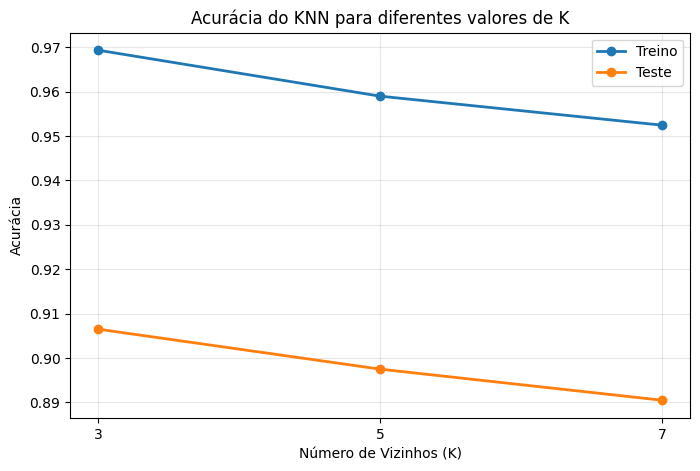

In [47]:
plt.figure(figsize=(8,5))

plt.plot(resultado_knn["K"],
         resultado_knn["Acurácia Treino"],
         marker="o",
         linewidth=2,
         label="Treino")

plt.plot(resultado_knn["K"],
         resultado_knn["Acurácia Teste"],
         marker="o",
         linewidth=2,
         label="Teste")

plt.title("Acurácia do KNN para diferentes valores de K")
plt.xlabel("Número de Vizinhos (K)")
plt.ylabel("Acurácia")

plt.xticks([3,5,7])

plt.grid(alpha=0.3)

plt.legend()

plt.show()

### Interpretação de Resultados
Realizamos 3 configurações para o hiperparâmetro **n_neighbors** (K = 3, 5 e 7).
Confirmamos que a melhor configuração encontrada foi a **K = 3**, com acurácia de **96,93%** no treinamento e **90,65%** no conjunto de teste.
En todos as as configurações de **K** observou-se uma diferença de aproximadamente **6%** nas acurácias entre treinamento e testes, com um leve overfitting. Junto a isso, percebe-se que o modelo manteve a capacidade de generalização adequada, com desempenho consistente nos dados não utilizados no treinamento.
Notou-se uma redução da acurácia de treinamento e teste a medida em que o valor de "K" aumenta. Sendo assim, o aumento desses valores não melhora o desempenho do modelo KNN. Adicionamos o Grafico de Acurácia do KNN para exemplificar a comparação entre os desempenhos.

## Treinamento do Modelo Árvore de Decisão
Este algoritmo de treinamento superviionado faz suas classificações através de divisões sucessivas da base de dados, formando uma estrutura visual que se assemelha a uma árvore.
O hiperparâmetro **max_depth** será utilizado para avaliar sua influência, limitando a profundidade dos estágios da árvore.
Testaremos três configurações:
* max_depth = 3
* max_depth = 5
* max_depth = None (sem limite)

Com essa metodologia, podemos identificar qual a melhor capacidade de generalização para reduzir o risco de overfitting.


In [48]:
#Treinamento da Árvore de Decisão
resultados_tree = []

for profundidade in [3, 5, None]:

    arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )

    arvore.fit(X_train_tree, y_train_balanceado)

    pred_train = arvore.predict(X_train_tree)
    pred_test = arvore.predict(X_test_tree)

    acc_train = accuracy_score(y_train_balanceado, pred_train)
    acc_test = accuracy_score(y_test, pred_test)

    resultados_tree.append({
        "Profundidade": profundidade if profundidade is not None else "Sem limite",
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test
    })

In [49]:
# Resultados
resultado_tree = pd.DataFrame(resultados_tree)

resultado_tree

,Profundidade,Acurácia Treino,Acurácia Teste
0,3,0.856903,0.847
1,5,0.902639,0.902
2,Sem limite,0.995601,0.942


In [50]:
# Melhor configuração encontrada
melhor_tree = resultado_tree.loc[
    resultado_tree["Acurácia Teste"].idxmax()
]

print(melhor_tree)

Profundidade       Sem limite
Acurácia Treino      0.995601
Acurácia Teste          0.942
Name: 2, dtype: object


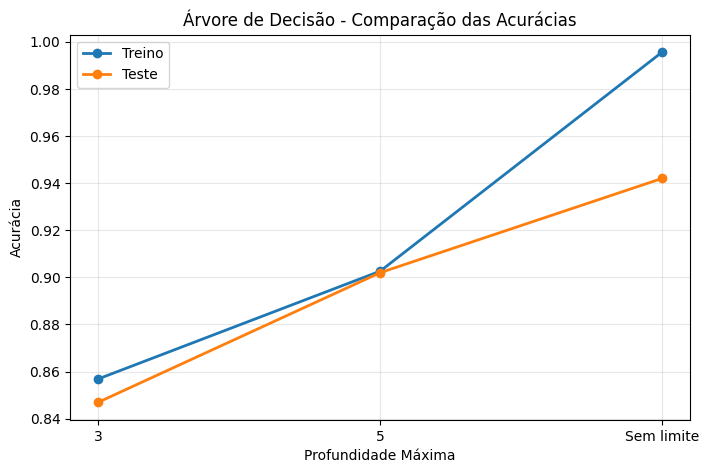

In [51]:
#Gráfico Comprativo entre Profundidade na Árvore de Decisão
plt.figure(figsize=(8,5))

plt.plot(
    resultado_tree["Profundidade"].astype(str),
    resultado_tree["Acurácia Treino"],
    marker="o",
    linewidth=2,
    label="Treino"
)

plt.plot(
    resultado_tree["Profundidade"].astype(str),
    resultado_tree["Acurácia Teste"],
    marker="o",
    linewidth=2,
    label="Teste"
)

plt.title("Árvore de Decisão - Comparação das Acurácias")

plt.xlabel("Profundidade Máxima")

plt.ylabel("Acurácia")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

### Interpretação dos Resultados
Conforme o treinamento e testes das três configurações do hiperparâmetro **max_depth** para a profundidade da Árvore de Decisão, foi evidenciado:
*   A profundidade **3** teve um depempenho inferior, o que mostra que a limitação a uma quantidade rasa de profundidade reduz a capacidade de evidenciar padrões da base de dados;
*   A profundidade **5* obteve um desempenho balanceado tanto no treinamento quanto nos testes, sem evidências de overfitting;
*   A profundidade **none** não limitou o crescimento da árvore e proporcionou a mlehor configuração, obtendo-se **99,56%** de acurácia no treinamento e **94,20%** no conjunto de teste. Mesmo que esta diferença de 5,36% entre o treinamento e o teste caracterize um leve overfitting, consideramos que essa configuração apresentou o melhor resultado entre as avaliadas

# Fase 7 - Comparação dos Modelos
Após a configuração dos modelos e ajuste dos hiperparâmetros, faremos a comparação entre o K-Nearest Neighbors (KNN) e Árvore de Decisão.
A base comparativa entre os modelos será avaliada pela acurácia dos conjuntos de teste, que mostra qual dos algoritmos apresenta a melhor capacidade de generalização para identificar possíveis falhas nos equipamentos industriais antes que aconteçam.
Faremos uma apresentação numérica e técnica sobre os resultados encontrados nestes modelos para justificar a escolha.

In [52]:
#Criando Tabela Comparativa dos Modelos

comparacao_modelos = pd.DataFrame({

    "Modelo": [
        "KNN (K=3)",
        "Árvore de Decisão (Sem limite)"
    ],

    "Acurácia Treino": [
        melhor_knn["Acurácia Treino"],
        melhor_tree["Acurácia Treino"]
    ],

    "Acurácia Teste": [
        melhor_knn["Acurácia Teste"],
        melhor_tree["Acurácia Teste"]
    ]

})

comparacao_modelos

,Modelo,Acurácia Treino,Acurácia Teste
0,KNN (K=3),0.969336,0.9065
1,Árvore de Decisão (Sem limite),0.995601,0.9420


### Comparação inicial dos Modelos
Abaixo se encontra a tabela com o desempenho das melhores configurações de KNN e Árvore de Decisão.
Foram consideradas as acurácias nos modelos de treinamento e teste, medindo os desempenhos e capacidade de generalização dos modelos.

In [53]:
# Tabela Comparativa de Acurácia
comparacao_modelos["Diferença (%)"] = (
    (comparacao_modelos["Acurácia Treino"] -
     comparacao_modelos["Acurácia Teste"])*100
).round(2)

comparacao_modelos

,Modelo,Acurácia Treino,Acurácia Teste,Diferença (%)
0,KNN (K=3),0.969336,0.9065,6.28
1,Árvore de Decisão (Sem limite),0.995601,0.9420,5.36


### Interpretação de Resultados
Calculamos as diferenças entre as acurácias de treinamento e teste para evidenciar possíveis casos de overfitting.
Entende-se que a melhor capacidade de generalização dos modelos apresentam menores diferenças entre treinamento e teste. Nos dados apresentados, tanto KNN e a Árvore de Decisão apresentaram diferenças pequenas, o que demonstra baixa possibilidade de overfitting. Mesmo assim, o modelo de Árvore de Decisão obteve números melhores de acurácia no conjunto de teste, sendo escolhido como o modelo de melhor desempenho.

In [54]:
comparacao_percentual = comparacao_modelos.copy()

comparacao_percentual["Acurácia Treino"] = (
    comparacao_percentual["Acurácia Treino"]*100
).round(2)

comparacao_percentual["Acurácia Teste"] = (
    comparacao_percentual["Acurácia Teste"]*100
).round(2)

comparacao_percentual

,Modelo,Acurácia Treino,Acurácia Teste,Diferença (%)
0,KNN (K=3),96.93,90.65,6.28
1,Árvore de Decisão (Sem limite),99.56,94.20,5.36


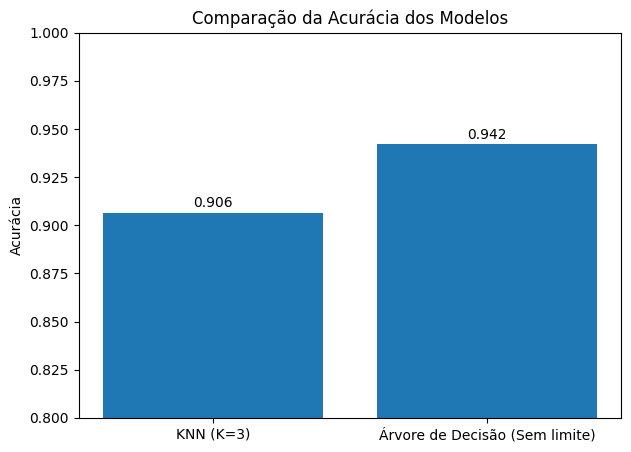

In [55]:
# Gráfico Comparativo entre os modelos na fase de teste
plt.figure(figsize=(7,5))

plt.bar(
    comparacao_modelos["Modelo"],
    comparacao_modelos["Acurácia Teste"]
)

plt.title("Comparação da Acurácia dos Modelos")

plt.ylabel("Acurácia")

plt.ylim(0.80,1.00)

for i, valor in enumerate(comparacao_modelos["Acurácia Teste"]):
    plt.text(
        i,
        valor+0.003,
        f"{valor:.3f}",
        ha='center'
    )

plt.show()

### Interpretação dos Resultados
O Gráfico evidencia o desempenho superior da Árvore de Decisão em relação ao KNN no conjunto de testes.
Mesmo que tenha apresentando um leve overfitting na diferença de treinamento e teste, não foi evidenciado o comprometimento da capacidade de generalização.

# Avaliação Detalhada do Modelo Selecionado
Comparados os modelos e selecionando a Árvore de Decisão como a escolha de melhor desempenho.
Realizaremos verificações complementares pela matriz de Confusão e Relatório de Classificação para avaliar o comportamento do modelo escolhido.

In [56]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [57]:
modelo_final = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

modelo_final.fit(
    X_train_tree,
    y_train_balanceado
)

y_pred = modelo_final.predict(X_test_tree)

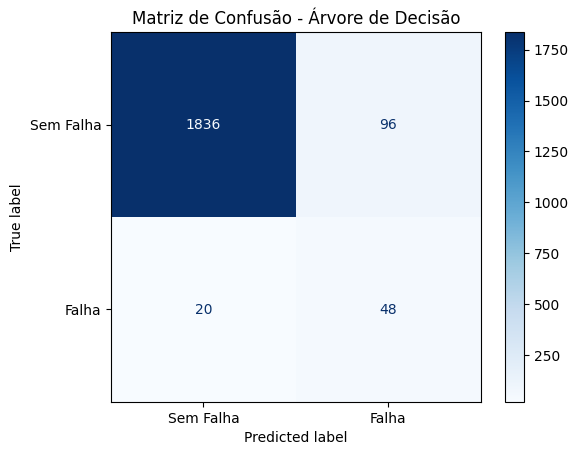

In [58]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem Falha", "Falha"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - Árvore de Decisão")

plt.grid(False)

plt.show()

In [59]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Sem Falha", "Falha"]
    )
)

              precision    recall  f1-score   support

   Sem Falha       0.99      0.95      0.97      1932
       Falha       0.33      0.71      0.45        68

    accuracy                           0.94      2000
   macro avg       0.66      0.83      0.71      2000
weighted avg       0.97      0.94      0.95      2000



### Interpretação dos Resultados
A Matriz de Confusão do modelo de Árvore de Decisão demonstrou que o modelo classificou corretamente os 1.836 equipamentos sem falha, 48 equipamentos com falha, **96 equipamentos sem falha foram classificados erroneamente com falha e 20 falhas reaias não foram encontradas**.
Avaliando o relatório de classificação, percebe-se que
*   há um ótimo desempenho para a classe **Sem Falha**, com Precisão de **0,99**, Recall de **0,95** e F1-Score de **0,97**;
*   para a classe **Falha**, a Precisão foi de **0,33**,  Recall de **0,71** e F1-Score de **0,45**. Mesmo com a precisão baixa caracterizada pelos falsos positivos, houve **71% das falhas reais identificadas pelo Recall**, o que é desejável em aplicações de manutenção preditiva, onde é melhor investigar um falso alarme do que deixar de encontrar uma falha real.
**Nota:**
*   **Precisão (Precision): **mede a confiabilidade das previsões de falha, indicando quantos dos equipamentos classificados como "Falha" realmente apresentavam uma falha;
*   **Recall (Revocação): **mede a capacidade do modelo de identificar corretamente os casos positivos reais, indicando quantas falhas reais foram detectadas;
*   **F1-Score: **representa o equilíbrio entre Precisão e Recall, fornecendo uma medida única do desempenho do modelo ao considerar simultaneamente a capacidade de detectar falhas e de evitar falsos alarmes.

Sendo assim, complementamos a análise de acurácia do modelo (94,20%), o que demostra que a Árvore de Decisão é capaz de identificar a maioria das falhas, mesmo que com um alto número de alertas de verificação.
Além disso, **foi utilizado o SMOTE somente no conjunto de treinamento**, conforme recomendado, deixando a **base de testes desbalanceada**, o que vai influenciar a precisão da classe **Falha**, mas ainda assim encontrando um Recall de 71%, priorizando a identificação de falhas reais.


# Conclusão do Projeto
Foram desenvolvidos dois modelos de Machine Learning para avaliar qual seria o mais adequado para a previsão de falhas em equipamentos industriais que utilizaram **K-Nearest Neighbors (KNN)** e **Árvore de Decisão**.
Durante o desenvolvimento, foram realizadas as etapas de **Análise Exploratória de Dados (EDA)**, **tratamento de dados ausentes/nulos**, **verificação de duplicidades**, **Engenharia de Atributos (Feature Egineering)**, **transformação de variáveis categórias**, **balanceamento de base de dados via SMOTE** e **escalonamento de variáveis contínuas para uso no algoritmo KNN**.
Através da avaliação dos hiperparâmetros encontrados para a realização das análises evidencio-se que:
*   O algoritmo KNN apresentou melhor desempenho quando o valor de **K = 3 (menor valor informad)**, atingindo **90,65%** de acurácia no conjunto de teste;
*   O algritmo de Árvore de Decisão mostrou o melhor desempenho com o hiperparâmetro **max_depth = None (sem limitação de profundidade de camadas de divisão)**, obtendo **94,20%** de acurácia no conjunto de testes.

Entendendo que mesmo que o algoritmo de Árvore de Decisão tenha apresentado um leve overfitting com diferença de **5,36%** entre a base de treinamento e a base de teste, não foi comprovada perda de capacidade de generalização, o que levou a estabelecer que o algoritmo de Árvore de Decisão apresentou o melhor desempenho para a base de dados informada.

Sendo assim, recomendamos a utilização da **Árvore de Decisão** como algoritmo de identificação de falhas em equipamentos indutriais por possuir maior precisão em previsões de falhas, melhorando as ações de manutenção preditiva.



## Trabalhos Futuros
Embora encontrados resultados satisfatórios nos modelos desenvolvidos, recomenda-se algumas melhorias para trabalhos futuros:
*   **Avaliação com outras métricas tipo Precision, Recall e F1-Score**, em bases desbalanceadas como na base de dados apresentada (que possuía cerca de 3,4% dos registros apresentando falha), para avaliar melhor a capacidade do algoritmo de identificas as falhas corretamente sem aumentar demais os alarmes falsos;
*   **Utilização de validação cruzada (Cross Validation)**, permitindo treinar e avaliar o modelo com diferentes divisões de dados para reduzir a dependência de uma única separação entre treinamento e teste e melhorando a confiabilidade do modelo;
*   **Otimização automatica de hiperparâmetros através de GridSearchCV**, para testar automaticamente combinações diferentes de parâmetros dos algoritmos, o que aumenta a probabilidade de encontro de configurações que performam melhor dos que as definidas manualmente;
*   **Avaliação de algoritmos mais robustos (Ramdom Forest, XGBoost, Gradient Boosting, etc.)**, baseados em conjuntos de árvores de decisão e técnicas de aprendizado em conjunto (Ensemble Learning), que podem construir relações mais complexas entre as variáveis e melhorar a precisão das previsões;
*   **Inclusão de novas variáveis dos sensores industriais**, onde novos atributos que se relacionam ao estado de operação dos equipamentos auxiliam na adição de informações ao modelo, o que aumenta sua capacidade de reconhecer padõres relacionadas à falhas, melhorando o desempenho da solução.

